# BRFSS 2015 Diabetes Health Indicators — Predictive Models

**Authors:** Wolfgang Klein, Sydney Bailey, Harvey Luna, Nashita Kandaker
**Data:** `diabetes_012_health_indicators_BRFSS2015.csv`, target collapsed to binary
(prediabetes and diabetes both coded 1)

## Intro

In [Lab 1](https://lone-wolfgang.github.io/brfss2015-diabetes-eda/#Lab1/WolfgangKlein)
we explored a dataset that links health, demographics, and income to a diabetes
diagnosis. See Lab 1 for the full data review.

Here we build predictive models with logistic regression and support vector machines (SVM),
compare their performance, and then compare what each model learns about the features.

## Models

We train two model families: logistic regression and support vector machines (SVM).

**Logistic regression** is fast to fit. If its assumptions hold, the coefficients
are easy to interpret. Non-linear effects can be added with squared terms and
interactions.

**SVM** learns a boundary between the classes; with a non-linear kernel it becomes non-parametric. The
main choice is the kernel: linear (fast), polynomial (curved boundaries), or RBF
(most flexible, slowest).

Lab 1 supported logistic regression, and a first model reached an AUC of 0.814.
We expect logistic regression to perform about as well as the SVMs. The non-linear kernels
fit slowly, so they are first tried on a subset. If one shows a significant gain, a full
hyperparameter sweep is run on that kernel.

## Metrics

The model flags people at risk of diabetes so they can be referred for screening.
Missing a case is costly, and so is an unnecessary referral.

- **Recall**: the share of true cases the model flags. Higher recall means fewer
  people with a serious, progressive disease go undetected.
- **Precision**: the share of flags that are true cases. Higher precision means
  fewer screening resources spent on people who don't have the disease.

Because missing a case is the more costly error, models are compared on **F2**,
which weights recall more heavily than precision:

$$
F_2 = \frac{(1 + 2^2)\cdot \text{Precision} \cdot \text{Recall}}{2^2 \cdot \text{Precision} + \text{Recall}}
    = \frac{5 \cdot \text{Precision} \cdot \text{Recall}}{4 \cdot \text{Precision} + \text{Recall}}
$$

## 0. Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import (roc_curve, roc_auc_score, precision_recall_curve,
                             fbeta_score, precision_score, recall_score, confusion_matrix)

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

PALETTE = {
    "ink":    "#22303c",
    "grid":   "#dfe4e8",
    "neg":    "#8fa3b0",   # reference / unexposed
    "pos":    "#b5442e",   # diabetes / elevated
    "prot":   "#2f6f6a",   # protective direction
    "accent": "#c98a1b",
}
SEQ = sns.blend_palette(["#f5f2ea", "#d8b26a", "#b5442e", "#5c1d13"], as_cmap=True)

mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 110,
    "font.size": 10.5, "axes.titlesize": 12, "axes.titleweight": "bold",
    "axes.labelsize": 10.5, "axes.edgecolor": PALETTE["grid"],
    "axes.grid": True, "grid.color": PALETTE["grid"], "grid.linewidth": 0.7,
    "axes.axisbelow": True, "axes.spines.top": False, "axes.spines.right": False,
    "text.color": PALETTE["ink"], "axes.labelcolor": PALETTE["ink"],
    "xtick.color": PALETTE["ink"], "ytick.color": PALETTE["ink"],
    "legend.frameon": False, "figure.facecolor": "white",
})

SEED = 0
print("pandas", pd.__version__, "| numpy", np.__version__, "| statsmodels", sm.__version__)

pandas 3.0.2 | numpy 2.4.4 | statsmodels 0.15.0


In [2]:
import os

PATH = "../data/diabetes_012_health_indicators_BRFSS2015.csv"
assert os.path.exists(PATH), f"Dataset not found at {PATH}. See README for setup."

raw = pd.read_csv(PATH)
raw["Diabetes_binary"] = (raw["Diabetes_012"] > 0).astype(int)
raw = raw.drop(columns="Diabetes_012")

TARGET = "Diabetes_binary"
print(f"shape   : {raw.shape[0]:,} rows x {raw.shape[1]} columns")
print(f"target  : {TARGET}, prevalence {100*raw[TARGET].mean():.2f}%")

shape   : 253,680 rows x 22 columns
target  : Diabetes_binary, prevalence 15.76%


## 1. Feature Considerations

Three changes, all from Lab 1:

- **Drop `CholCheck`.** Lab 1 §11 showed it tracks access to a doctor, not disease.
- **Winsorize BMI at 70.** Values above 70 are a data artifact.
- **Add squared terms for Age and Income.** Both curves bend. Each is centered
  before squaring.

In [3]:
df = raw.drop(columns="CholCheck").copy()
df["BMI"] = np.minimum(df["BMI"], 70)

for col in ["Age", "Income"]:
    df[col] = df[col] - df[col].mean()
    df[f"{col}_sq"] = df[col] ** 2

FEATURES = [c for c in df.columns if c != TARGET]
print(f"{len(FEATURES)} features:", ", ".join(FEATURES))

22 features: HighBP, HighChol, BMI, Smoker, Stroke, HeartDiseaseorAttack, PhysActivity, Fruits, Veggies, HvyAlcoholConsump, AnyHealthcare, NoDocbcCost, GenHlth, MentHlth, PhysHlth, DiffWalk, Sex, Age, Education, Income, Age_sq, Income_sq


## 2. Splits

The data is split 70 / 15 / 15, stratified on the target.

- **train (70%)**: fits the model. For the SVMs, it is also used for tuning with
  5-fold CV.
- **validation (15%)**: picks the decision threshold.
- **test (15%)**: final, unbiased score at the chosen threshold.

In [4]:
X, y = df[FEATURES], df[TARGET]

X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=SEED)

display(pd.DataFrame({
    "rows":         [len(y_train), len(y_val), len(y_test)],
    "share %":      [100*len(y_train)/len(y), 100*len(y_val)/len(y), 100*len(y_test)/len(y)],
    "prevalence %": [100*y_train.mean(), 100*y_val.mean(), 100*y_test.mean()],
}, index=["train", "validation", "test"]).round(2))

,rows,share %,prevalence %
train,177576,70.0000,15.7600
validation,38052,15.0000,15.7600
test,38052,15.0000,15.7600


## 3. Logistic Regression

The model is fit on the training set. Its coefficients are interpreted in §7.

In [5]:
logit = sm.Logit(y_train, sm.add_constant(X_train)).fit(disp=0)
print(f"McFadden pseudo-R2: {logit.prsquared:.4f}")

McFadden pseudo-R2: 0.2067


## 4. SVM Kernel Screen

Non-linear SVM kernels can capture patterns a linear model misses, but they take
much longer to train. This screen checks whether their gains are worth the extra time.

- Each kernel is fit on 50,000 rows sampled from `train` and scored by AUC on the
  rest of `train`.
- Every model uses `class_weight="balanced"`. Without it, the non-linear SVMs rank
  poorly.
- A non-linear kernel is kept only if it beats logistic regression by at least
  **0.005 AUC**.
- The linear SVM is fast, so it is always kept.

This cell can take up to 30 minutes. Progress prints as each trial finishes. The slow
trials run first, so the first lines take a few minutes to appear. Each finished
trial is saved to `cache/kernel_screen.jsonl`. If the run is stopped, running the
cell again skips the trials already saved.

In [6]:
import json, time
from pathlib import Path
from joblib import Parallel, delayed
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC, LinearSVC
from sklearn.linear_model import LogisticRegression

SCREEN_ROWS = 50_000
X_fit, X_ev, y_fit, y_ev = train_test_split(
    X_train, y_train, train_size=SCREEN_ROWS, stratify=y_train, random_state=SEED)

TRIALS  = [dict(kernel="logistic")]
TRIALS += [dict(kernel="linear", C=C) for C in [0.01, 0.1, 1, 10]]
TRIALS += [dict(kernel="poly", degree=2, C=C, coef0=c0) for C in [0.1, 1, 10] for c0 in [0.5, 1, 2]]
TRIALS += [dict(kernel="poly", degree=3, C=C, coef0=c0) for C in [0.1, 1] for c0 in [1, 2]]
TRIALS += [dict(kernel="rbf", C=C, gamma=g) for C in [0.1, 1, 10] for g in [0.003, 0.01, 0.03]]
TRIALS += [dict(kernel="sigmoid", C=C, gamma=g, coef0=0) for C in [0.1, 1, 10] for g in [0.0003, 0.001, 0.003]]

# slowest first: large C, then the costlier kernels
COST = {"rbf": 3, "poly": 2, "sigmoid": 1, "linear": 0, "logistic": 0}
TRIALS.sort(key=lambda t: (-t.get("C", 0), -COST[t["kernel"]]))


def build(t):
    p = {k: v for k, v in t.items() if k != "kernel"}
    if t["kernel"] == "logistic":
        est = LogisticRegression(max_iter=2000, class_weight="balanced")
    elif t["kernel"] == "linear":
        est = LinearSVC(class_weight="balanced", **p)
    else:
        est = SVC(kernel=t["kernel"], class_weight="balanced", cache_size=2000, **p)
    return make_pipeline(StandardScaler(), est)


def run_trial(t):
    model = build(t)
    t0 = time.perf_counter(); model.fit(X_fit, y_fit); fit_s = time.perf_counter() - t0
    t0 = time.perf_counter(); s = model.decision_function(X_ev); score_s = time.perf_counter() - t0
    est = model[-1]
    return dict(params=t, auc=roc_auc_score(y_ev, s), fit_s=fit_s, score_s=score_s,
                n_support=int(est.n_support_.sum()) if hasattr(est, "n_support_") else None)


def label(t):
    return " ".join([t["kernel"]] + [f"{k}={v}" for k, v in t.items() if k != "kernel"])


LOG = Path("cache/kernel_screen.jsonl")
LOG.parent.mkdir(exist_ok=True)
key  = lambda t: json.dumps(t, sort_keys=True)
done = {key(json.loads(line)["params"]) for line in LOG.read_text().splitlines()} if LOG.exists() else set()
todo = [t for t in TRIALS if key(t) not in done]
print(f"{len(TRIALS)} trials: {len(done)} already saved, {len(todo)} to run "
      f"(fit on {len(y_fit):,} rows, score on {len(y_ev):,})", flush=True)

start = time.perf_counter()
jobs  = Parallel(n_jobs=12, return_as="generator_unordered")(delayed(run_trial)(t) for t in todo)
for i, r in enumerate(jobs, 1):
    with LOG.open("a") as f:
        f.write(json.dumps(r) + "\n")
    print(f"[{i:2d}/{len(todo)}] {(time.perf_counter() - start) / 60:5.1f} min | "
          f"{label(r['params']):<34} AUC {r['auc']:.4f} | "
          f"fit {r['fit_s']:6.1f}s  score {r['score_s']:6.1f}s", flush=True)
print(f"finished in {(time.perf_counter() - start) / 60:.1f} min")


36 trials: 36 already saved, 0 to run (fit on 50,000 rows, score on 127,576)
finished in 0.0 min


All trials, sorted by AUC.

In [7]:
rows = [json.loads(line) for line in LOG.read_text().splitlines()]
screen = pd.DataFrame([{**r["params"], "AUC": r["auc"], "fit s": r["fit_s"],
                        "score s": r["score_s"], "support vectors": r["n_support"]} for r in rows])
screen = screen[["kernel", "degree", "C", "gamma", "coef0",
                 "AUC", "fit s", "score s", "support vectors"]]
screen = screen.sort_values("AUC", ascending=False).reset_index(drop=True)
PARAM_FMT = {c: (lambda v: "" if pd.isna(v) else f"{v:g}")
             for c in ["degree", "C", "gamma", "coef0", "support vectors"]}
display(screen.style.format({**PARAM_FMT, "AUC": "{:.4f}", "fit s": "{:.1f}", "score s": "{:.1f}"})
        .hide(axis="index"))


kernel,degree,C,gamma,coef0,AUC,fit s,score s,support vectors
rbf,,1,0.003,,0.8189,56.9,142.4,29706
rbf,,0.1,0.01,,0.8183,59.0,113.7,30031
rbf,,10,0.003,,0.8178,53.7,137.7,28967
poly,2,0.1,,2,0.8176,45.3,44.0,28972
poly,2,0.1,,1,0.8175,47.9,44.3,29023
poly,2,0.1,,0.5,0.8174,48.3,44.7,29109
rbf,,1,0.01,,0.8173,55.3,137.4,29012
poly,2,1,,1,0.8170,41.6,43.0,28738
poly,2,1,,2,0.8170,43.6,42.9,28738
poly,2,1,,0.5,0.8170,34.0,43.6,28754


Best trial per kernel, compared with logistic regression.

In [8]:
KEEP_GAP = 0.005
lr_auc = screen.loc[screen.kernel == "logistic", "AUC"].iloc[0]

best = screen.loc[screen.groupby("kernel").AUC.idxmax()].sort_values("AUC", ascending=False)
best["gap vs logistic"] = best.AUC - lr_auc
# linear is cheap, so it stays in the overnight search regardless; the rule applies to the others
best["decision"] = np.select(
    [best.kernel == "logistic", best.kernel == "linear", best["gap vs logistic"] >= KEEP_GAP],
    ["baseline", "keep (cheap)", "keep"], "drop")
display(best[["kernel", "degree", "C", "gamma", "coef0", "AUC", "gap vs logistic", "decision"]]
        .style.format({**PARAM_FMT, "AUC": "{:.4f}", "gap vs logistic": "{:+.4f}"}, subset=None)
        .hide(axis="index"))


kernel,degree,C,gamma,coef0,AUC,gap vs logistic,decision
rbf,,1,0.003,,0.8189,+0.0022,drop
poly,2,0.1,,2,0.8176,+0.0009,drop
logistic,,,,,0.8167,+0.0000,baseline
linear,,10,,,0.8163,-0.0004,keep (cheap)
sigmoid,,10,0.001,0,0.8158,-0.0009,drop


### Linear SVM tuning

The screen showed that the non-linear kernels do not beat logistic
regression by enough to justify their training time, so the SVM is **linear**.

Its hyperparameters are tuned on the full training set with stratified **5-fold CV**.
Folds are scored on AUC, which does not depend on a threshold. The threshold is picked
on the validation set in §5.

- `C`: 15 values from 1e-5 to 1e2 (log scale)
- `penalty`: L1 (sparse coefficients) or L2
- `class_weight`: none or balanced

Many settings tie on AUC, so the model is chosen with the **one-standard-error rule**. Every
setting whose mean CV AUC is within one standard error of the best is treated as tied.
Among those, the one with the smallest `C` (the strongest regularization) is kept.

The model uses **squared hinge loss**, which penalizes misclassified points by the
square of their distance from the margin. It is solved in the primal
(`dual=False`), which scales with the number of features rather than rows and fits
the full training set in under a second. Plain hinge loss would require the dual
solver, which scales with the number of rows and takes minutes per fit here.
Squared hinge is also required for the L1 penalty in `LinearSVC`.

In [9]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

N_FOLDS = 5
SVM_GRID = {
    "linearsvc__C":            np.logspace(-5, 2, 15),
    "linearsvc__penalty":      ["l1", "l2"],
    "linearsvc__class_weight": [None, "balanced"],
}


def one_se(cv_results):
    """Smallest C whose mean CV AUC is within one standard error of the best."""
    auc = cv_results["mean_test_AUC"]
    top = int(np.argmax(auc))
    tol = cv_results["std_test_AUC"][top] / np.sqrt(N_FOLDS)
    tied = np.flatnonzero(auc >= auc[top] - tol)
    C = np.asarray(cv_results["param_linearsvc__C"], dtype=float)[tied]
    return int(tied[np.lexsort((-auc[tied], C))][0])   # smallest C, then highest AUC


svm_search = GridSearchCV(
    make_pipeline(StandardScaler(), LinearSVC(dual=False, max_iter=10_000, random_state=SEED)),
    SVM_GRID,
    cv=StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED),
    scoring={"AUC": "roc_auc", "AP": "average_precision"},
    refit=one_se, n_jobs=-1)

t0 = time.perf_counter()
svm_search.fit(X_train, y_train)
svm = svm_search.best_estimator_
res = svm_search.cv_results_
print(f"{len(res['params'])} configurations x {N_FOLDS} folds "
      f"in {time.perf_counter() - t0:.1f}s")
print(f"best CV AUC     : {res['mean_test_AUC'].max():.4f}")
print("selected (1 SE) :", {k.split("__")[1]: v for k, v in svm_search.best_params_.items()},
      f"| CV AUC {res['mean_test_AUC'][svm_search.best_index_]:.4f}")

60 configurations x 5 folds in 9.4s
best CV AUC     : 0.8161
selected (1 SE) : {'C': np.float64(3.1622776601683795e-05), 'class_weight': 'balanced', 'penalty': 'l2'} | CV AUC 0.8156


CV AUC for every setting. The shaded band is the tie region: within one standard error
of the best. The circled point is the selected model. L1 at C ≤ 3e-5 falls below the
plotted range; at C = 1e-5 with no class weights, L1 zeroes every coefficient and AUC is 0.5.

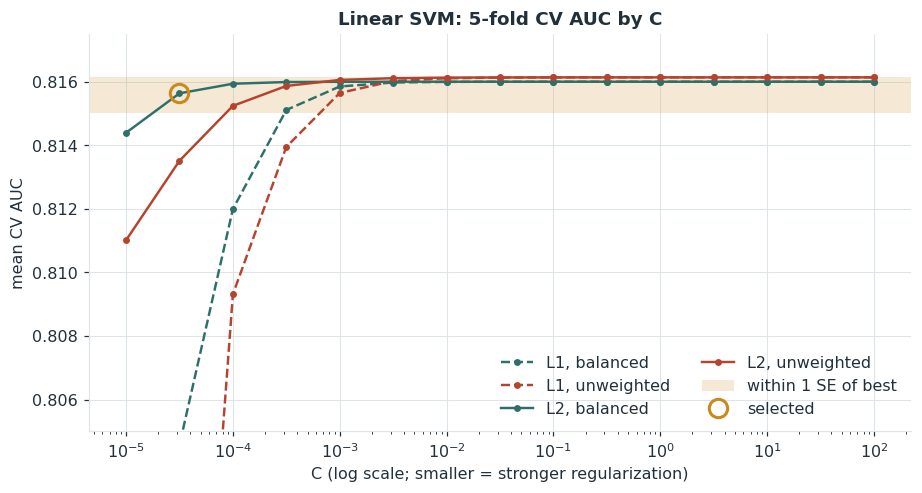

In [10]:
cv = pd.DataFrame(res)
cv["C"]            = cv["param_linearsvc__C"].astype(float)
cv["penalty"]      = cv["param_linearsvc__penalty"]
cv["class_weight"] = cv["param_linearsvc__class_weight"].fillna("none")
top = cv["mean_test_AUC"].idxmax()
tol = cv.loc[top, "std_test_AUC"] / np.sqrt(N_FOLDS)
sel = svm_search.best_index_

fig, ax = plt.subplots(figsize=(8.5, 4.6))
colors = {"none": PALETTE["pos"], "balanced": PALETTE["prot"]}
for (pen, cw), g in cv.groupby(["penalty", "class_weight"]):
    ax.plot(g["C"], g["mean_test_AUC"], color=colors[cw], ls="--" if pen == "l1" else "-",
            marker="o", ms=3.5, lw=1.6, label=f"{pen.upper()}, {'unweighted' if cw == 'none' else 'balanced'}")
ax.axhspan(cv.loc[top, "mean_test_AUC"] - tol, cv.loc[top, "mean_test_AUC"],
           color=PALETTE["accent"], alpha=.18, lw=0, label="within 1 SE of best")
ax.plot(cv.loc[sel, "C"], cv.loc[sel, "mean_test_AUC"], "o", ms=12, mfc="none",
        mec=PALETTE["accent"], mew=2, label="selected")
ax.set_xscale("log"); ax.set_ylim(0.805, 0.8175)
ax.set_xlabel("C (log scale; smaller = stronger regularization)"); ax.set_ylabel("mean CV AUC")
ax.set_title("Linear SVM: 5-fold CV AUC by C"); ax.legend(loc="lower right", ncol=2)
plt.tight_layout(); plt.show()

**Why the curve is flat.** AUC depends only on how the model ranks people. For a linear
model the ranking comes from the *direction* of the weight vector; scaling the weights
changes nothing. With about 177,000 training rows and only 22 features, the data pins that
direction down tightly. Once `C` is above about 0.01 the penalty is negligible, and every
setting, L1 or L2, converges on the same model. Class weighting mostly shifts the
intercept, which does not affect ranking. Tuning only matters at heavy regularization,
where the penalty starts to shrink or drop real signal.

For the same reason the linear SVM and logistic regression end up with nearly the same
AUC (§6): both find nearly the same direction in the same 22 features. Better scores would
have to come from the features (interactions or new variables), not from hyperparameters.

Top 10 settings by mean CV AUC, plus the selected one.

In [11]:
show = cv.sort_values("mean_test_AUC", ascending=False).head(10).index.union([sel])
cv_table = pd.DataFrame({
    "C":            cv["C"],
    "penalty":      cv["penalty"],
    "class_weight": cv["class_weight"],
    "CV AUC":       cv["mean_test_AUC"],
    "AUC sd":       cv["std_test_AUC"],
    "CV AP":        cv["mean_test_AP"],
    "fit s":        cv["mean_fit_time"],
    "selected":     np.where(cv.index == sel, "✓", ""),
}).loc[show].sort_values("CV AUC", ascending=False)
display(cv_table.style.format({"C": "{:.2e}", "CV AUC": "{:.4f}", "AUC sd": "{:.4f}",
                               "CV AP": "{:.4f}", "fit s": "{:.2f}"}).hide(axis="index"))

C,penalty,class_weight,CV AUC,AUC sd,CV AP,fit s,selected
3.16e+00,l1,none,0.8161,0.0025,0.4365,0.38,
1.00e+01,l1,none,0.8161,0.0025,0.4365,0.35,
1.00e+02,l1,none,0.8161,0.0025,0.4365,0.40,
3.16e+01,l1,none,0.8161,0.0025,0.4365,0.33,
1.00e+02,l2,none,0.8161,0.0025,0.4365,0.33,
3.16e+01,l2,none,0.8161,0.0025,0.4365,0.31,
1.00e+01,l2,none,0.8161,0.0025,0.4365,0.33,
3.16e+00,l2,none,0.8161,0.0025,0.4365,0.33,
1.00e+00,l2,none,0.8161,0.0025,0.4365,0.37,
1.00e+00,l1,none,0.8161,0.0025,0.4365,0.35,


## 5. Threshold Tuning

Each model's threshold is picked on the validation set. The plots show precision,
recall, and F2 at each threshold, and the threshold with the highest F2 is marked.
Logistic regression is on the left and the linear SVM is on the right.

Logistic regression outputs a probability. The SVM outputs a signed distance from its
boundary, so its thresholds are on that scale. Its plot covers the central 99% of
validation scores.

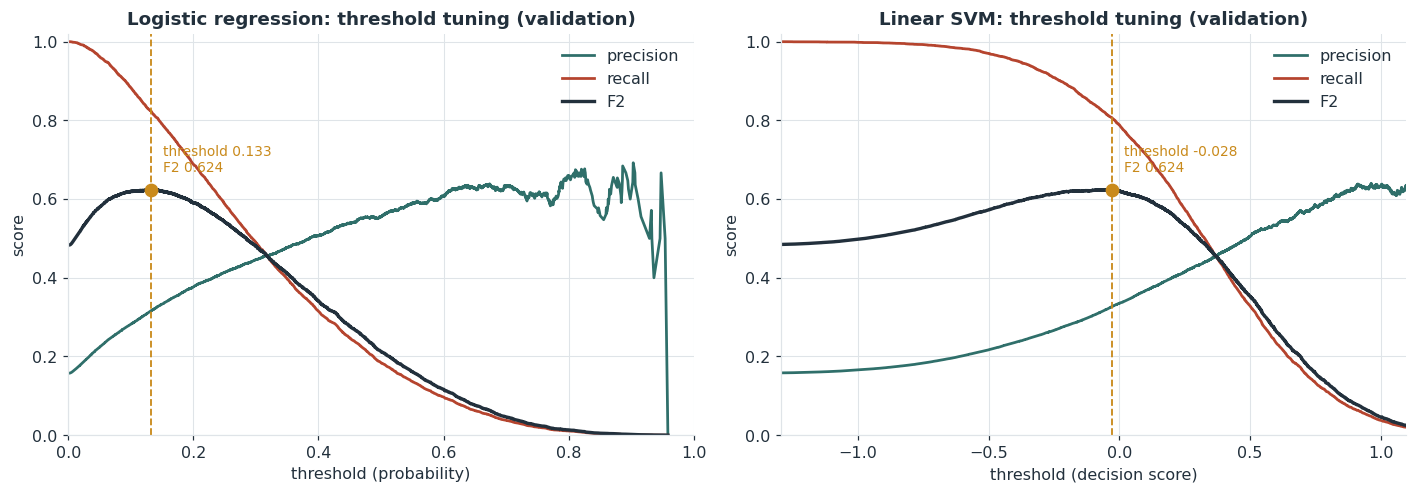

Logistic regression  threshold +0.133: precision 0.317, recall 0.823, F2 0.624
Linear SVM           threshold -0.028: precision 0.327, recall 0.807, F2 0.624


In [12]:
def f2_curve(y_true, s):
    """Precision, recall, and F2 at every threshold."""
    prec, rec, thr = precision_recall_curve(y_true, s)
    prec, rec = prec[:-1], rec[:-1]
    f2 = np.where(prec + rec > 0, 5 * prec * rec / (4 * prec + rec), 0)
    return thr, prec, rec, f2


def tune(ax, name, s_val, xlim=(0, 1), xlabel="threshold"):
    """Plot precision, recall, and F2 by threshold; return the max-F2 operating point."""
    thr, prec, rec, f2 = f2_curve(y_val, s_val)
    i = int(np.argmax(f2))

    ax.plot(thr, prec, color=PALETTE["prot"], lw=1.8, label="precision")
    ax.plot(thr, rec,  color=PALETTE["pos"],  lw=1.8, label="recall")
    ax.plot(thr, f2,   color=PALETTE["ink"],  lw=2.2, label="F2")
    ax.axvline(thr[i], color=PALETTE["accent"], ls="--", lw=1.2)
    ax.plot(thr[i], f2[i], "o", color=PALETTE["accent"], ms=8)
    ax.annotate(f"threshold {thr[i]:.3f}\nF2 {f2[i]:.3f}", (thr[i], f2[i]),
                xytext=(8, 12), textcoords="offset points", color=PALETTE["accent"], fontsize=9)
    ax.set_xlim(*xlim); ax.set_ylim(0, 1.02)
    ax.set_xlabel(xlabel); ax.set_ylabel("score")
    ax.set_title(f"{name}: threshold tuning (validation)"); ax.legend(loc="upper right")
    return dict(threshold=thr[i], val_precision=prec[i], val_recall=rec[i], val_f2=f2[i])


p_val_lr  = logit.predict(sm.add_constant(X_val))
s_val_svm = svm.decision_function(X_val)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
TUNED = {
    "Logistic regression": tune(axes[0], "Logistic regression", p_val_lr,
                                xlabel="threshold (probability)"),
    "Linear SVM":          tune(axes[1], "Linear SVM", s_val_svm,
                                xlim=np.percentile(s_val_svm, [0.5, 99.5]),
                                xlabel="threshold (decision score)"),
}
plt.tight_layout(); plt.show()

for name, t in TUNED.items():
    print(f"{name:<20} threshold {t['threshold']:+.3f}: precision {t['val_precision']:.3f}, "
          f"recall {t['val_recall']:.3f}, F2 {t['val_f2']:.3f}")

## 6. Results

ROC curves for both models on the test set.

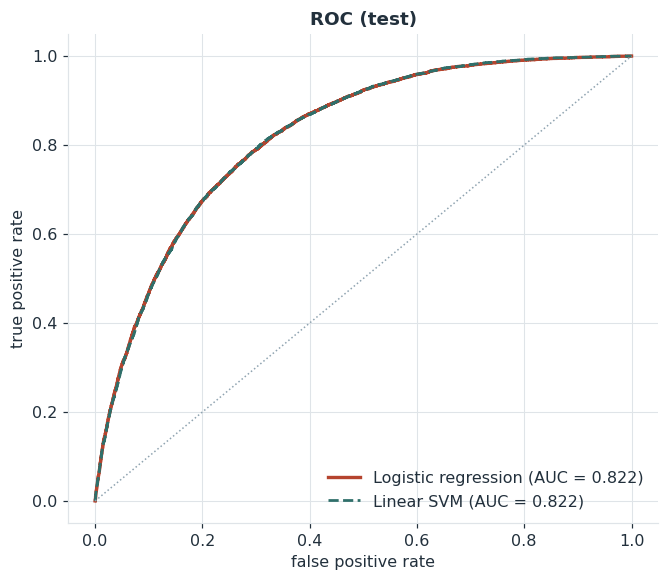

In [13]:
p_test_lr  = logit.predict(sm.add_constant(X_test))
s_test_svm = svm.decision_function(X_test)

RESULTS = {
    "Logistic regression": dict(**TUNED["Logistic regression"], s_test=p_test_lr),
    "Linear SVM":          dict(**TUNED["Linear SVM"],          s_test=s_test_svm),
}
STYLE = {"Logistic regression": dict(color=PALETTE["pos"],  lw=2.2),
         "Linear SVM":          dict(color=PALETTE["prot"], lw=1.8, ls="--")}

fig, ax = plt.subplots(figsize=(6.2, 5.4))
for name, r in RESULTS.items():
    fpr, tpr, _ = roc_curve(y_test, r["s_test"])
    ax.plot(fpr, tpr, **STYLE[name], label=f"{name} (AUC = {roc_auc_score(y_test, r['s_test']):.3f})")
ax.plot([0, 1], [0, 1], color=PALETTE["neg"], ls=":", lw=1)
ax.set_xlabel("false positive rate"); ax.set_ylabel("true positive rate")
ax.set_title("ROC (test)"); ax.legend(loc="lower right")
plt.tight_layout(); plt.show()

Each model is scored at its tuned threshold on the validation set (where the
threshold was picked) and on the test set. Models are ranked by test F2.

In [14]:
rows = []
for name, r in RESULTS.items():
    pred = r["s_test"] >= r["threshold"]
    rows.append({
        ("", "Model"):               name,
        ("Validation", "Precision"): r["val_precision"],
        ("Validation", "Recall"):    r["val_recall"],
        ("Validation", "F2"):        r["val_f2"],
        ("Test", "Precision"):       precision_score(y_test, pred),
        ("Test", "Recall"):          recall_score(y_test, pred),
        ("Test", "F2"):              fbeta_score(y_test, pred, beta=2),
    })
results = pd.DataFrame(rows)
results.columns = pd.MultiIndex.from_tuples(results.columns)
results = results.sort_values(("Test", "F2"), ascending=False).reset_index(drop=True)
results.insert(0, ("", "Rank"), range(1, len(results) + 1))
display(results.style.format("{:.4f}", subset=results.columns[2:]).hide(axis="index"))

Confusion matrix for the best model on the test set.

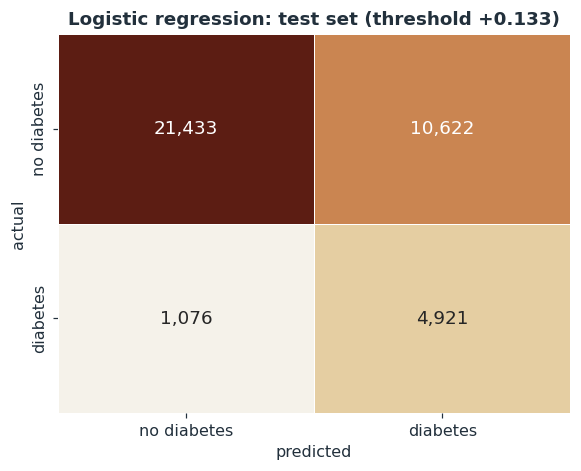

recall    : 0.821  (4,921 of 5,997 cases flagged)
precision : 0.317  (4,921 of 15,543 flags are cases)


In [15]:
best = results.iloc[0][("", "Model")]
r = RESULTS[best]
cm = confusion_matrix(y_test, r["s_test"] >= r["threshold"])

fig, ax = plt.subplots(figsize=(5.4, 4.4))
sns.heatmap(cm, annot=True, fmt=",d", cmap=SEQ, cbar=False, ax=ax,
            linewidths=.6, linecolor="white", annot_kws={"fontsize": 12},
            xticklabels=["no diabetes", "diabetes"], yticklabels=["no diabetes", "diabetes"])
ax.set_xlabel("predicted"); ax.set_ylabel("actual")
ax.set_title(f"{best}: test set (threshold {r['threshold']:+.3f})")
plt.tight_layout(); plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"recall    : {tp/(tp+fn):.3f}  ({tp:,} of {tp+fn:,} cases flagged)")
print(f"precision : {tp/(tp+fp):.3f}  ({tp:,} of {tp+fp:,} flags are cases)")

## 7. Interpretation

The logistic regression coefficients, with odds ratios and 95% confidence intervals. Each
effect holds the other features fixed.

In [16]:
ci = logit.conf_int()
params = pd.DataFrame({
    "coef":       logit.params,
    "ci_low":     ci[0],
    "ci_high":    ci[1],
    "odds_ratio": np.exp(logit.params),
    "or_low":     np.exp(ci[0]),
    "or_high":    np.exp(ci[1]),
    "p_value":    logit.pvalues,
})
display(params.round(4))

,coef,ci_low,ci_high,odds_ratio,or_low,or_high,p_value
const,-5.5032,-5.6442,-5.3623,0.0041,0.0035,0.0047,0.0000
HighBP,0.6953,0.6630,0.7277,2.0044,1.9405,2.0704,0.0000
HighChol,0.5714,0.5412,0.6016,1.7708,1.7180,1.8251,0.0000
BMI,0.0647,0.0626,0.0669,1.0669,1.0646,1.0692,0.0000
Smoker,-0.0295,-0.0591,0.0001,0.9709,0.9426,1.0001,0.0504
Stroke,0.1153,0.0577,0.1729,1.1222,1.0593,1.1887,0.0001
HeartDiseaseorAttack,0.2175,0.1767,0.2584,1.2430,1.1933,1.2948,0.0000
PhysActivity,-0.0472,-0.0796,-0.0147,0.9539,0.9235,0.9854,0.0044
Fruits,-0.0446,-0.0752,-0.0139,0.9564,0.9275,0.9862,0.0044
Veggies,-0.0463,-0.0819,-0.0106,0.9548,0.9213,0.9895,0.0110


Odds ratios above 1 raise the risk, and below 1 lower it. For binary features, the
odds ratio compares a 1 to a 0. For the others, it is the change per one unit.

### Primary risk factors

BMI is the primary risk factor. Every unit increase in BMI is associated with a **6.7%**
increase in the odds of a diabetes diagnosis (CI: 6.5%–6.9%). The effect compounds: a
5-point difference in BMI raises the odds by about 38%.

High blood pressure doubles the odds, an increase of **100%** (CI: 94%–107%). High
cholesterol raises the odds by **77%** (CI: 72%–83%).

### Comorbidities

Diabetes often comes with other chronic conditions. A history of heart disease or heart
attack raises the odds of diabetes by **24%** (CI: 19%–29%), a history of stroke by **12%**
(CI: 6%–19%), and difficulty walking by **9%** (CI: 5%–13%).

These are associations. Correlation does not imply causation. Diabetes itself raises
the risk of heart disease and stroke, so the arrow can point either way. The effects are
also modest because BMI, blood pressure, and general health, which are in the same model,
already carry much of the same signal.

### Demographics

**Sex.** Men have **27%** higher odds of a diabetes diagnosis than women (CI: 23%–31%),
with the other factors accounted for.

**Age.** Age is coded in 13 five-year groups, from 18–24 up to 80+. It enters the model as a
centered linear term plus its square, so no single coefficient gives its effect. Each group
is compared with the youngest (18–24) through a contrast. For centered age codes $a_k$, the
difference in log odds is

$$\beta_{\text{Age}}\,(a_k - a_1) + \beta_{\text{Age}^2}\,(a_k^2 - a_1^2),$$

and its confidence interval uses the coefficient covariance matrix, so the uncertainty in both
terms is included.

In [17]:
AGE_GROUPS = ["18–24", "25–29", "30–34", "35–39", "40–44", "45–49", "50–54",
              "55–59", "60–64", "65–69", "70–74", "75–79", "80+"]
a = np.arange(1, 14) - raw["Age"].mean()          # centered age codes, as in §1

L = np.zeros((len(a), len(logit.params)))
L[:, logit.params.index.get_loc("Age")]    = a - a[0]
L[:, logit.params.index.get_loc("Age_sq")] = a**2 - a[0]**2
contrast = logit.t_test(L[1:])                    # every group vs 18–24
lo, hi = contrast.conf_int().T

age_table = pd.DataFrame({
    "log odds":   np.r_[0, contrast.effect],
    "ci_low":     np.r_[np.nan, lo],
    "ci_high":    np.r_[np.nan, hi],
    "odds_ratio": np.r_[1, np.exp(contrast.effect)],
    "or_low":     np.r_[np.nan, np.exp(lo)],
    "or_high":    np.r_[np.nan, np.exp(hi)],
}, index=pd.Index(AGE_GROUPS, name="age group"))
display(age_table.style.format("{:.3f}", na_rep="ref"))

,log odds,ci_low,ci_high,odds_ratio,or_low,or_high
age group,,,,,,
18–24,0.000,ref,ref,1.000,ref,ref
25–29,0.410,0.384,0.437,1.507,1.467,1.548
30–34,0.780,0.730,0.829,2.181,2.076,2.292
35–39,1.109,1.040,1.178,3.032,2.829,3.249
40–44,1.398,1.313,1.483,4.048,3.717,4.408
45–49,1.647,1.549,1.745,5.190,4.706,5.724
50–54,1.855,1.748,1.962,6.391,5.741,7.115
55–59,2.023,1.909,2.136,7.559,6.749,8.467
60–64,2.150,2.034,2.267,8.586,7.643,9.647


Age has the largest effect in the model. Relative to 18–24, the odds rise steeply through
middle age: about **4.0 times** at 40–44 (CI: 3.7–4.4), **6.4 times** at 50–54 (CI: 5.7–7.1),
and **8.6 times** at 60–64 (CI: 7.6–9.6). The curve flattens after 65 and peaks at 75–79,
at **9.9 times** the odds (CI: 8.8–11.0), with a slight dip at 80+.

The squared term forces a smooth curve, so the dip at 80+ comes partly from that shape. It
may also reflect survivorship: people with diabetes are less likely to reach 80.

### Health and habits

**General health** is the strongest of these. It is rated from 1 (excellent) to 5 (poor), and
each step worse raises the odds by **66%** (CI: 63%–69%). Someone reporting poor health has
about 7.6 times the odds of someone reporting excellent health.

**Heavy drinking** is associated with **50%** lower odds (CI: 46%–54%). This is unlikely to
be protective. People with diabetes are often told to cut back on alcohol, so the
diagnosis may be driving the habit rather than the reverse.

**Healthy habits** have small effects. Eating fruit daily, eating vegetables daily, and any
physical activity in the past month each lower the odds by about **4–5%** (CIs from about
1% to 8%). **Smoking** has no clear effect once the other features are included (−2.9%,
CI: −5.7% to 0.0%).

**Days of poor mental and physical health** in the past month (0–30) lower the odds
slightly: **0.4%** and **0.6%** per day, or about 11% and 17% across all 30 days. The
negative sign is likely a result of adjusting for general health. At the same general
health rating, more bad days probably reflect problems other than diabetes.

### Linear SVM vs logistic regression

Does the SVM learn the same thing as logistic regression? Both are linear, so each gives
one weight per feature. The SVM is fit on standardized features, so its weights are per
standard deviation. The logistic regression coefficients are put on the same scale
(coefficient × the feature's SD).

The SVM's weights are much smaller in absolute terms, because its strong regularization
(C ≈ 3e-5) shrinks them. In the left panel they are rescaled to the same overall length as
the logistic regression weights. Only their relative sizes affect how people are ranked.

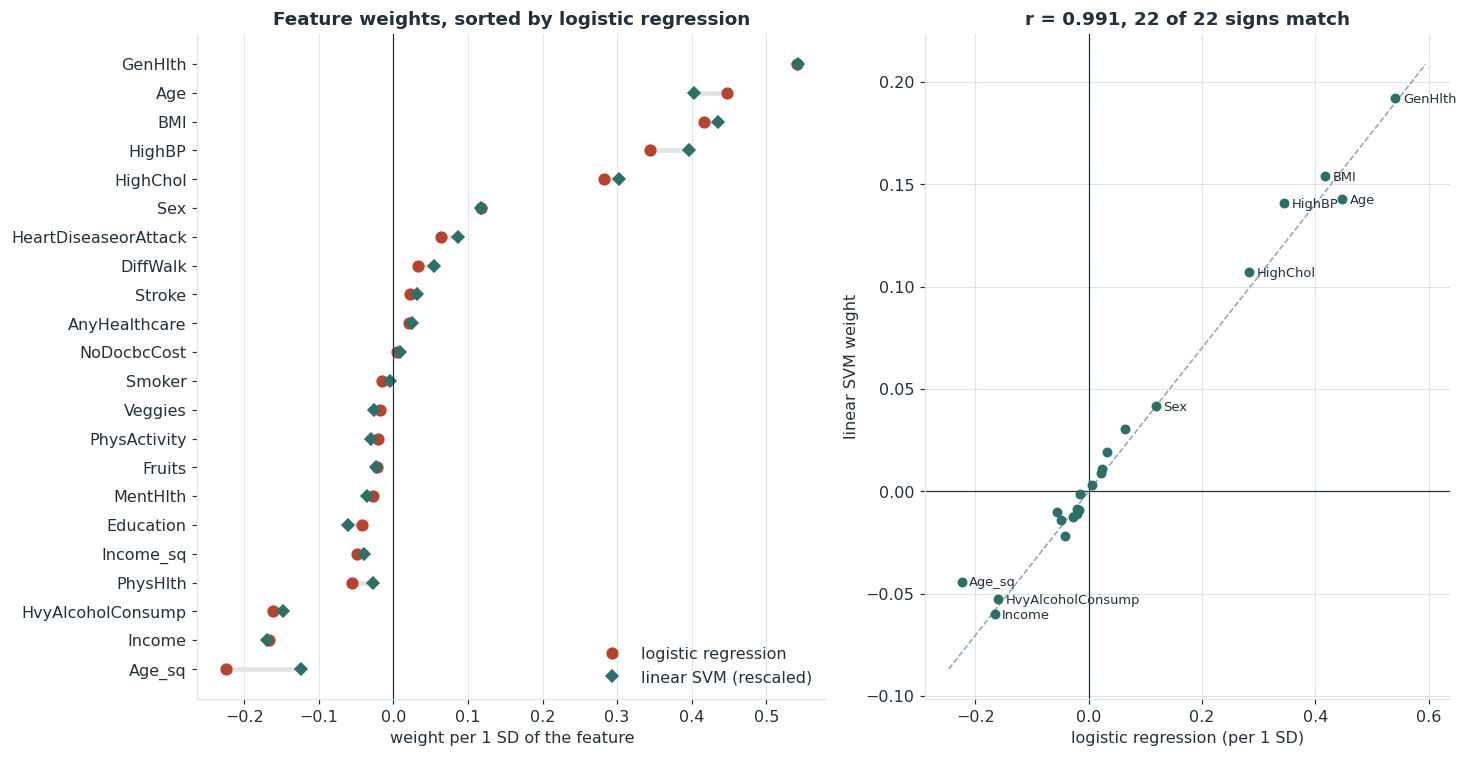

In [18]:
w_svm = pd.Series(svm[-1].coef_[0], index=FEATURES)
b_lr  = logit.params[FEATURES] * X_train.std()       # per 1 SD, the SVM's input scale
w_rescaled = w_svm * np.linalg.norm(b_lr) / np.linalg.norm(w_svm)
r     = np.corrcoef(b_lr, w_svm)[0, 1]
agree = int((np.sign(b_lr) == np.sign(w_svm)).sum())
order = b_lr.sort_values().index

fig, axes = plt.subplots(1, 2, figsize=(13.5, 7), gridspec_kw={"width_ratios": [1.2, 1]})

ax = axes[0]
yy = np.arange(len(order))
ax.hlines(yy, b_lr[order], w_rescaled[order], color=PALETTE["grid"], lw=3)
ax.plot(b_lr[order], yy, "o", color=PALETTE["pos"], ms=7, label="logistic regression")
ax.plot(w_rescaled[order], yy, "D", color=PALETTE["prot"], ms=5.5, label="linear SVM (rescaled)")
ax.axvline(0, color=PALETTE["ink"], lw=0.8)
ax.set_yticks(yy, order); ax.grid(axis="y", visible=False)
ax.set_xlabel("weight per 1 SD of the feature")
ax.set_title("Feature weights, sorted by logistic regression"); ax.legend(loc="lower right")

ax = axes[1]
slope = (b_lr @ w_svm) / (b_lr @ b_lr)                 # least-squares line through the origin
xs = np.array([b_lr.min(), b_lr.max()]) * 1.1
ax.plot(xs, slope * xs, color=PALETTE["neg"], ls="--", lw=1)
ax.axhline(0, color=PALETTE["ink"], lw=0.8); ax.axvline(0, color=PALETTE["ink"], lw=0.8)
ax.scatter(b_lr, w_svm, color=PALETTE["prot"], s=30, zorder=3)
for f in b_lr.abs().sort_values(ascending=False).index[:9]:
    ax.annotate(f, (b_lr[f], w_svm[f]), xytext=(5, -3), textcoords="offset points",
                fontsize=8.5, color=PALETTE["ink"])
ax.set_xlabel("logistic regression (per 1 SD)"); ax.set_ylabel("linear SVM weight")
ax.set_title(f"r = {r:.3f}, {agree} of {len(b_lr)} signs match")

plt.tight_layout(); plt.show()

The two models agree almost perfectly. Their weights correlate at about r = 0.99, and every
feature has the same sign in both. The same features lead both models. General health, age,
BMI, high blood pressure, and high cholesterol push the score up the most. The squared age
term, income, and heavy drinking pull it down the most. The findings above therefore do not
depend on the choice of logistic regression.

The SVM shrinks some weights more than others, most of all smoking, days of poor physical
health, and the squared age term. That is expected from its stronger regularization, and
none of them changes sign.

**Support vectors.** A support vector is a training row on or inside the margin,
$y \cdot f(x) < 1$ with $y = \pm 1$. The SVM's weights are built only from these rows.

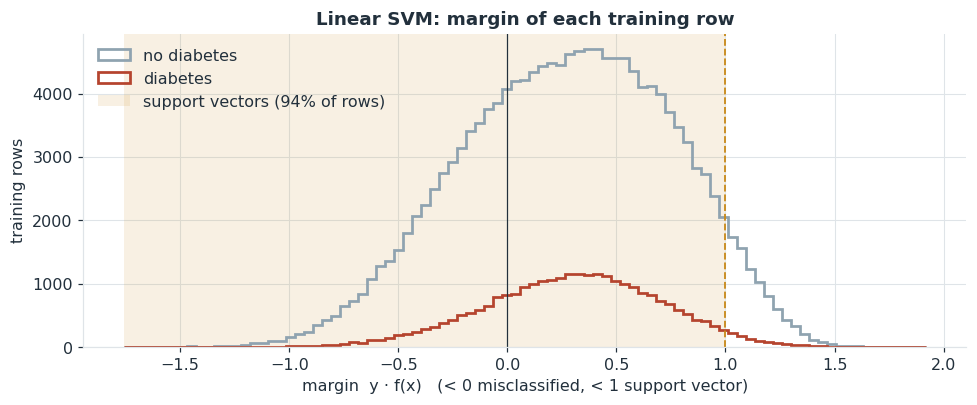

no diabetes : 140,834 of 149,592 rows are support vectors (94.1%)
diabetes    :  26,946 of  27,984 rows are support vectors (96.3%)


In [19]:
margin = np.where(y_train == 1, 1, -1) * svm.decision_function(X_train)
is_sv  = margin < 1

fig, ax = plt.subplots(figsize=(9, 3.8))
bins = np.linspace(margin.min(), margin.max(), 90)
for cls, name in [(0, "no diabetes"), (1, "diabetes")]:
    ax.hist(margin[y_train == cls], bins=bins, histtype="step", lw=1.8,
            color=PALETTE["neg"] if cls == 0 else PALETTE["pos"], label=name)
ax.axvspan(margin.min(), 1, color=PALETTE["accent"], alpha=.12, lw=0,
           label=f"support vectors ({is_sv.mean():.0%} of rows)")
ax.axvline(1, color=PALETTE["accent"], ls="--", lw=1.2)
ax.axvline(0, color=PALETTE["ink"], lw=0.8)
ax.set_xlabel("margin  y · f(x)   (< 0 misclassified, < 1 support vector)"); ax.set_ylabel("training rows")
ax.set_title("Linear SVM: margin of each training row"); ax.legend(loc="upper left")
plt.tight_layout(); plt.show()

for cls, name in [(0, "no diabetes"), (1, "diabetes")]:
    m = y_train.values == cls
    print(f"{name:<12}: {is_sv[m].sum():>7,} of {m.sum():>7,} rows are support vectors ({is_sv[m].mean():.1%})")

Because the selected model is strongly regularized, its margin is wide. About 94% of
non-diabetic rows and 96% of diabetic rows are support vectors, so no small set of rows defines the boundary. The SVM's weights summarize nearly the whole training set, just as logistic
regression does, which is why the two models agree so closely.

## 8. Conclusion

Logistic regression and the linear SVM performed almost identically. On the test set, logistic
regression scored an F2 of 0.622 and the SVM 0.621. The non-linear kernels improved AUC by at
most 0.002, which was not worth their training time. The two models also agree on what matters:
age, general health, BMI, high blood pressure, and high cholesterol are the strongest risk
factors. These are associations, not causes.

The next step is a better representation of the cost of diabetes and the cost of intervention.
In absolute terms, the best model returned about twice as many false positives as true positives
(10,622 vs 4,921), while missing about 18% of cases. On one hand, doctors' time is expensive, and
screening is a burden for patients. On the other hand, an early diagnosis is a chance to change
someone's life for the better.

F2 is useful because it weights recall over precision, but it is only a convenient estimate of
that trade-off. With a better estimate of the cost of intervention and the cost of a missed
diagnosis, the decision threshold could be calibrated to those costs, and the case for
intervention would be stronger.
